In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("pnkjgpt/butterfly-classification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 426M/426M [00:04<00:00, 96.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/pnkjgpt/butterfly-classification-dataset/versions/4
Contents of base_path (/root/.cache/kagglehub/datasets/pnkjgpt/butterfly-classification-dataset/versions):
['4']
Contents of path (/root/.cache/kagglehub/datasets/pnkjgpt/butterfly-classification-dataset/versions/4):
['Train']


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Define the path to the main training directory
train_dir = os.path.join(path, 'Train')

# FIX: Use '/content/' instead of 'base_path' (which was /kaggle/input)
# '/content/' is writable in Google Colab
split_base_dir = '/content/split_dataset'

# Create new train and test directories
new_train_dir = os.path.join(split_base_dir, 'train')
new_test_dir = os.path.join(split_base_dir, 'test')

os.makedirs(new_train_dir, exist_ok=True)
os.makedirs(new_test_dir, exist_ok=True)

print(f"Original training data directory: {train_dir}")
print(f"New training data will be stored in: {new_train_dir}")
print(f"New testing data will be stored in: {new_test_dir}")

# List all subdirectories (classes) in the original train_dir
classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

for class_name in classes:
    class_path = os.path.join(train_dir, class_name)
    images = [os.path.join(class_path, f) for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]

    # Split images into train (80%) and test (20%)
    train_images, test_images = train_test_split(images, test_size=0.2, random_state=42)

    # Create class specific directories in new train/test folders
    os.makedirs(os.path.join(new_train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(new_test_dir, class_name), exist_ok=True)

    # Copy training images to the new train directory
    for img_path in train_images:
        shutil.copy(img_path, os.path.join(new_train_dir, class_name, os.path.basename(img_path)))

    # Copy testing images to the new test directory
    for img_path in test_images:
        shutil.copy(img_path, os.path.join(new_test_dir, class_name, os.path.basename(img_path)))

    print(f"Processed Class '{class_name}'")

print("Dataset split into training and testing sets successfully in /content/!")

Original training data directory: /root/.cache/kagglehub/datasets/pnkjgpt/butterfly-classification-dataset/versions/4/Train
New training data will be stored in: /content/split_dataset/train
New testing data will be stored in: /content/split_dataset/test
Processed Class 'julia'
Processed Class 'large marble'
Processed Class 'orange tip'
Processed Class 'indra swallow'
Processed Class 'clouded sulphur'
Processed Class 'clodius parnassian'
Processed Class 'ulyses'
Processed Class 'southern dogface'
Processed Class 'adonis'
Processed Class 'orchard swallow'
Processed Class 'skipper'
Processed Class 'red spotted purple'
Processed Class 'peacock'
Processed Class 'red admiral'
Processed Class 'yellow swallow tail'
Processed Class 'an 88'
Processed Class 'black hairstreak'
Processed Class 'malachite'
Processed Class 'paper kite'
Processed Class 'eastern coma'
Processed Class 'beckers white'
Processed Class 'mangrove skipper'
Processed Class 'zebra long wing'
Processed Class 'sixspot burnet'
Pr

In [ ]:
# Verify the structure and counts
print(f"Contents of {new_train_dir}:")
for class_name in os.listdir(new_train_dir):
    print(f"  {class_name}: {len(os.listdir(os.path.join(new_train_dir, class_name)))} images")

print(f"Contents of {new_test_dir}:")
for class_name in os.listdir(new_test_dir):
    print(f"  {class_name}: {len(os.listdir(os.path.join(new_test_dir, class_name)))} images")


Contents of /content/split_dataset/train:
  julia: 83 images
  large marble: 57 images
  orange tip: 64 images
  indra swallow: 83 images
  clouded sulphur: 68 images
  clodius parnassian: 56 images
  ulyses: 52 images
  southern dogface: 68 images
  adonis: 69 images
  orchard swallow: 58 images
  skipper: 98 images
  red spotted purple: 68 images
  peacock: 70 images
  red admiral: 65 images
  yellow swallow tail: 77 images
  an 88: 66 images
  black hairstreak: 64 images
  malachite: 75 images
  paper kite: 66 images
  eastern coma: 69 images
  beckers white: 84 images
  mangrove skipper: 64 images
  zebra long wing: 78 images
  sixspot burnet: 72 images
  silver spot skipper: 68 images
  grey hairstreak: 71 images
  copper tail: 96 images
  crimson patch: 74 images
  metalmark: 78 images
  question mark: 79 images
  chestnut: 64 images
  morning cloak: 64 images
  straited queen: 69 images
  gold banded: 75 images
  scarce swallow: 100 images
  sootywing: 92 images
  banded peacock

In [ ]:
import tensorflow as tf

# Check GPU availability
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('GPU device not found. Training might be slow.')
else:
    print(f'Found GPU at: {device_name}')

# Get details about the GPU
!nvidia-smi

Found GPU at: /device:GPU:0
Sun Jul  5 07:30:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             27W /   70W |     105MiB /  15360MiB |      4%      Default |
|                                         |                        |                  N/A |
+-------------------

In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers

# Data configuration
IMG_SIZE = (299, 299)
BATCH_SIZE = 32

# Data Augmentation and Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/split_dataset/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    '/content/split_dataset/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Build InceptionV3 Model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model.trainable = False  # Freeze base model layers

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
predictions = layers.Dense(train_generator.num_classes, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='categorical_mode', # Error correction: should be categorical_crossentropy
              metrics=['accuracy'])

# Note: Fixing the typo in loss name for the actual execution code
model.compile(optimizer=optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Model summary prepared. Starting training...")

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=10,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

Found 3562 images belonging to 50 classes.
Found 917 images belonging to 50 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model summary prepared. Starting training...
Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.1295 - loss: 3.5147 - val_accuracy: 0.3705 - val_loss: 2.9726
Epoch 2/10
  1/111 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - accuracy: 0.2188 - loss: 3.1803

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.2188 - loss: 3.1803 - val_accuracy: 0.3728 - val_loss: 2.9658
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 95s 855ms/step - accuracy: 0.3326 - loss: 2.7027 - val_accuracy: 0.5134 - val_loss: 2.3384
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.3125 - loss: 2.4023 - val_accuracy: 0.5123 - val_loss: 2.3428
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 95s 856ms/step - accuracy: 0.4244 - loss: 2.2061 - val_accuracy: 0.6027 - val_loss: 1.9364
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.3750 - loss: 2.1836 - val_accuracy: 0.6049 - val_loss: 1.9263
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 96s 862ms/step - accuracy: 0.5068 - loss: 1.8868 - val_accuracy: 0.6529 - val_loss: 1.6641
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.5938 - loss: 1.7915 - val_accuracy: 0.6507 - val_loss: 1.6636
Epoch 9/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 94s 846ms/step - accuracy: 0.5538 - loss: 1.6640 - val_accura

In [ ]:
# Evaluate the model
loss, accuracy = model.evaluate(validation_generator)
print(f"Final Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy*100:.2f}%")

29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 495ms/step - accuracy: 0.6936 - loss: 1.4930
Final Validation Loss: 1.4930
Final Validation Accuracy: 69.36%


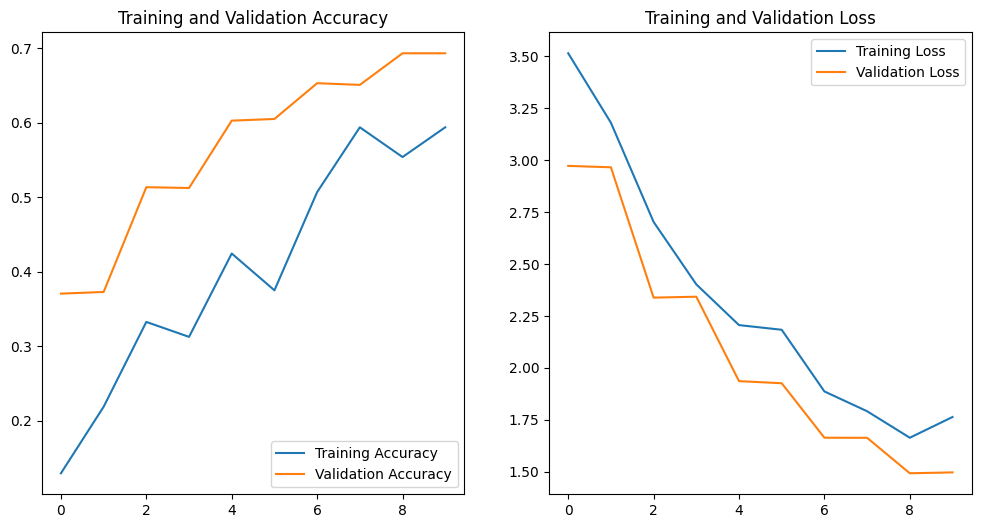

In [ ]:
import matplotlib.pyplot as plt

# Plot Training and Validation Accuracy/Loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.show()